### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [1]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [2]:
from keras.preprocessing import image
img_path = './images/lion.jpg'

I0000 00:00:1787291887.947036   11798 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


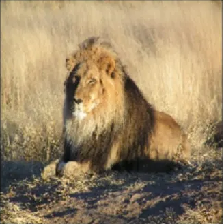

In [3]:
target_size=(224, 224)
img = image.load_img(img_path, target_size=target_size)
img

In [4]:
img_arr = image.img_to_array(img)
img_arr.shape

(224, 224, 3)

In [5]:
import numpy as np
img_arr_dim = np.expand_dims(img_arr, axis=0)
img_arr_dim.shape

(1, 224, 224, 3)

In [6]:
from keras.applications.resnet50 import preprocess_input
img_arr_dim_proc = preprocess_input(img_arr_dim)

In [7]:
"https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/preprocess_input"

'https://www.tensorflow.org/api_docs/python/tf/keras/applications/resnet50/preprocess_input'

In [8]:
from keras.applications.resnet50 import ResNet50
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


In [9]:
preds = model.predict(img_arr_dim_proc)
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


array([[2.83557323e-14, 1.37474464e-14, 8.67718115e-13, 1.39332149e-13,
        2.22648218e-14, 2.04071731e-13, 3.04860412e-13, 1.32729161e-10,
        1.28328069e-11, 3.53705509e-10, 1.03137854e-12, 1.35857428e-12,
        1.58776486e-12, 1.40763443e-12, 5.01856484e-14, 3.80344458e-14,
        3.34117472e-13, 8.60735582e-13, 1.88817237e-13, 5.49267608e-13,
        2.98068238e-13, 1.38952782e-11, 7.42473999e-11, 2.95094049e-12,
        4.89324184e-13, 3.65527731e-13, 2.44552317e-13, 2.10761001e-13,
        2.48226698e-14, 2.68304557e-13, 7.92170827e-14, 5.51215161e-14,
        7.72072185e-13, 8.81286851e-13, 1.58920696e-12, 4.25570332e-13,
        1.71622238e-13, 4.70422075e-14, 2.20792351e-12, 1.04863405e-12,
        8.69999229e-15, 3.31512270e-13, 3.60072188e-13, 1.60656211e-10,
        2.02518788e-13, 5.94528073e-12, 9.08874755e-14, 2.59269629e-13,
        3.49875207e-12, 1.03943677e-11, 2.16872537e-14, 3.40000380e-13,
        2.22524906e-12, 9.01198820e-13, 1.11244781e-12, 9.069698

In [10]:
from keras.applications.resnet50 import decode_predictions
decoded_pred = decode_predictions(preds, top=3)
decoded_pred

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


[[('n02129165', 'lion', np.float32(0.9999958)),
  ('n02106030', 'collie', np.float32(1.5381722e-06)),
  ('n02129604', 'tiger', np.float32(9.4652586e-07))]]

In [11]:
for p in decoded_pred[0]:
    print(p[1] ,": ", round(p[2]*100,2))

lion :  100.0
collie :  0.0
tiger :  0.0


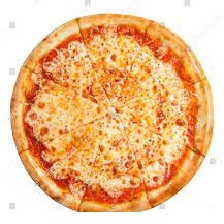

In [12]:
from keras.preprocessing import image
img_path = './images/pizza.jpg'
target_size=(224, 224)
img = image.load_img(img_path, target_size=target_size)
img

In [13]:
img_arr = image.img_to_array(img)
img_arr_dim = np.expand_dims(img_arr, axis=0)
img_arr_dim_proc = preprocess_input(img_arr_dim)
preds = model.predict(img_arr_dim_proc)
decoded_pred=decode_predictions(preds, top=3)
for p in decoded_pred[0]:
    print(p[1] ,": ", round(p[2]*100,2))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
pizza :  85.51
potpie :  11.14
eggnog :  0.81
